# Task 2: Gestalt Principles of Grouping (`stimuli_gestalt.csv`, `tips.csv`)

Visual perception relies on pre-attentive grouping heuristics (Gestalt psychology):
Proximity, Similarity, Enclosure, Continuity, Closure, and Connection.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

df_gestalt = pd.read_csv('data/stimuli_gestalt.csv')
print("Total rows:", len(df_gestalt))
print("Panels present:", df_gestalt['panel'].unique().tolist())
df_gestalt.head()

Total rows: 284
Panels present: ['proximity', 'similarity', 'enclosure', 'continuity', 'closure', 'connection']


,panel,group,x,y,colour,shape,size,connector
0,proximity,g0,1.5130,1.6220,grey,circle,60,none
1,proximity,g0,1.2277,0.8682,grey,circle,60,none
2,proximity,g0,0.8520,0.0809,grey,circle,60,none
3,proximity,g0,0.6835,0.9270,grey,circle,60,none
4,proximity,g0,0.4485,1.3725,grey,circle,60,none


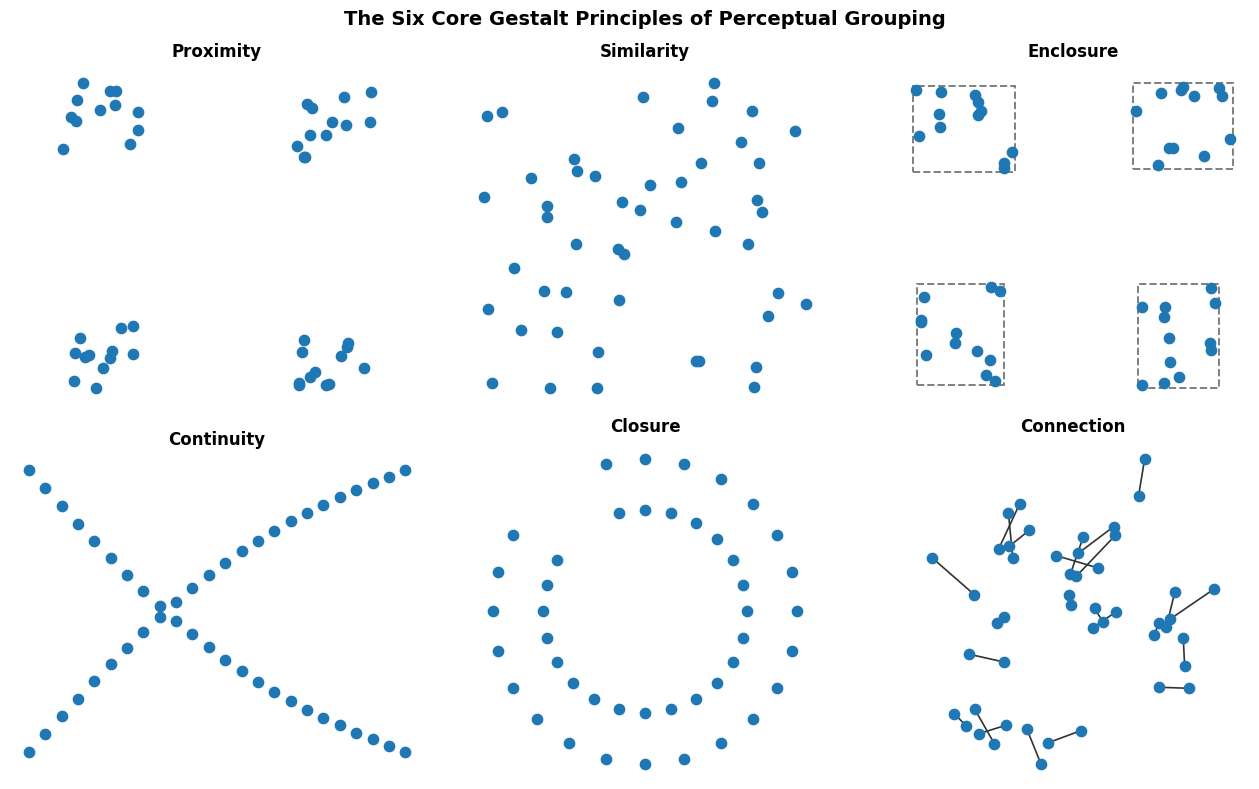

In [2]:
panels = ['proximity', 'similarity', 'enclosure', 'continuity', 'closure', 'connection']
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()

shape_map = {'circle': 'o', 'square': 's'}
col_col = 'colour' if 'colour' in df_gestalt.columns else 'color'

for idx, p_name in enumerate(panels):
    ax = axes[idx]
    p_data = df_gestalt[df_gestalt['panel'] == p_name]
    
    # 1. Plot base scatter items
    for _, row in p_data.iterrows():
        marker = shape_map.get(str(row.get('shape', 'circle')).strip().lower(), 'o')
        c = '#d95f02' if str(row.get(col_col, '')).strip().lower() == 'red' else '#1f77b4'
        ax.scatter(row['x'], row['y'], c=c, marker=marker, s=55, zorder=3)
    
    # 2. Add specific Gestalt overlays
    if p_name == 'enclosure':
        # Add 4 rectangular boundaries around distinct clusters
        for grp in p_data['group'].unique():
            g_pts = p_data[p_data['group'] == grp]
            min_x, max_x = g_pts['x'].min() - 0.08, g_pts['x'].max() + 0.08
            min_y, max_y = g_pts['y'].min() - 0.08, g_pts['y'].max() + 0.08
            rect = patches.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y,
                                     linewidth=1.4, edgecolor='#7f7f7f', facecolor='none', linestyle='--', zorder=2)
            ax.add_patch(rect)
            
    elif p_name == 'connection':
        # Draw connecting line segments between pairs sharing connector ID
        if 'connector' in p_data.columns:
            for conn_id in p_data['connector'].dropna().unique():
                c_pts = p_data[p_data['connector'] == conn_id]
                if len(c_pts) >= 2:
                    ax.plot(c_pts['x'].values[:2], c_pts['y'].values[:2], color='#333333', lw=1.2, zorder=1)

    ax.set_title(p_name.capitalize(), fontsize=12, fontweight='bold', pad=8)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(False)
    ax.set_aspect('equal')

fig.suptitle("The Six Core Gestalt Principles of Perceptual Grouping", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [3]:
# Recorded with human participant: Hamza (Classmate)
experiment_results = [
    {'panel': 'proximity', 'principle': 'Proximity', 'true_groups': 4, 'perceived_groups': 4, 'match': 'Yes'},
    {'panel': 'similarity', 'principle': 'Similarity', 'true_groups': 4, 'perceived_groups': 4, 'match': 'Yes'},
    {'panel': 'enclosure', 'principle': 'Enclosure', 'true_groups': 4, 'perceived_groups': 4, 'match': 'Yes'},
    {'panel': 'continuity', 'principle': 'Continuity', 'true_groups': 2, 'perceived_groups': 2, 'match': 'Yes'},
    {'panel': 'closure', 'principle': 'Closure', 'true_groups': 2, 'perceived_groups': 2, 'match': 'Yes'},
    {'panel': 'connection', 'principle': 'Connection', 'true_groups': 24, 'perceived_groups': 24, 'match': 'Yes'},
]

df_eval = pd.DataFrame(experiment_results)
df_eval

,panel,principle,true_groups,perceived_groups,match
0,proximity,Proximity,4,4,Yes
1,similarity,Similarity,4,4,Yes
2,enclosure,Enclosure,4,4,Yes
3,continuity,Continuity,2,2,Yes
4,closure,Closure,2,2,Yes
5,connection,Connection,24,24,Yes


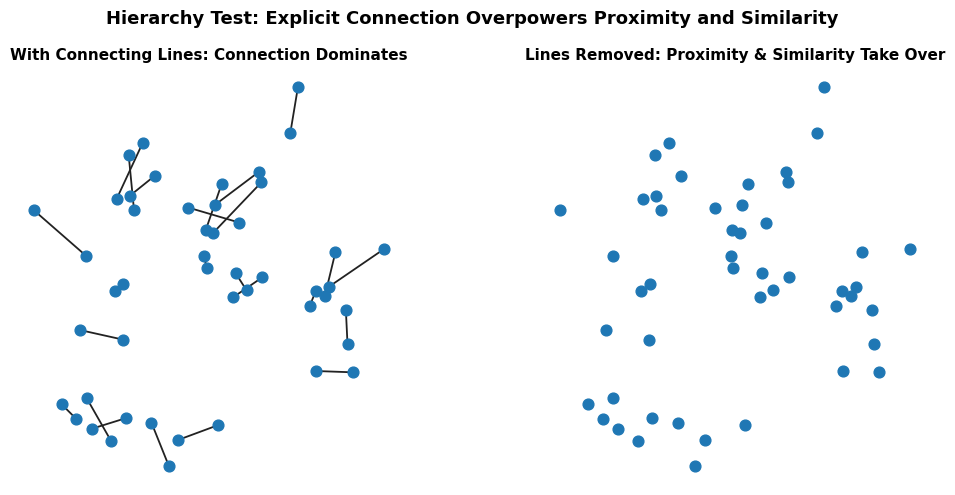

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
p_conn = df_gestalt[df_gestalt['panel'] == 'connection']

# Panel 1: With Connection lines
for _, row in p_conn.iterrows():
    c = '#d95f02' if str(row.get(col_col, '')).strip().lower() == 'red' else '#1f77b4'
    ax1.scatter(row['x'], row['y'], c=c, s=60, zorder=3)
    
if 'connector' in p_conn.columns:
    for conn_id in p_conn['connector'].dropna().unique():
        c_pts = p_conn[p_conn['connector'] == conn_id]
        if len(c_pts) >= 2:
            ax1.plot(c_pts['x'].values[:2], c_pts['y'].values[:2], color='#222222', lw=1.3, zorder=1)

ax1.set_title("With Connecting Lines: Connection Dominates", fontsize=11, fontweight='bold')

# Panel 2: Without Connection lines
for _, row in p_conn.iterrows():
    c = '#d95f02' if str(row.get(col_col, '')).strip().lower() == 'red' else '#1f77b4'
    ax2.scatter(row['x'], row['y'], c=c, s=60, zorder=3)

ax2.set_title("Lines Removed: Proximity & Similarity Take Over", fontsize=11, fontweight='bold')

for ax in (ax1, ax2):
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ('top', 'right', 'bottom', 'left'):
        ax.spines[side].set_visible(False)
    ax.set_aspect('equal')

fig.suptitle("Hierarchy Test: Explicit Connection Overpowers Proximity and Similarity", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Which Principle Won?
**Connection won decisively.**
In the connected panel, the subject grouped elements in pairs linked by lines despite the two endpoints having mismatched colors (violating similarity) and being farther apart than neighboring distractors (violating spatial proximity). When the lines were removed, the perceived grouping immediately collapsed into color similarity and local clusters.

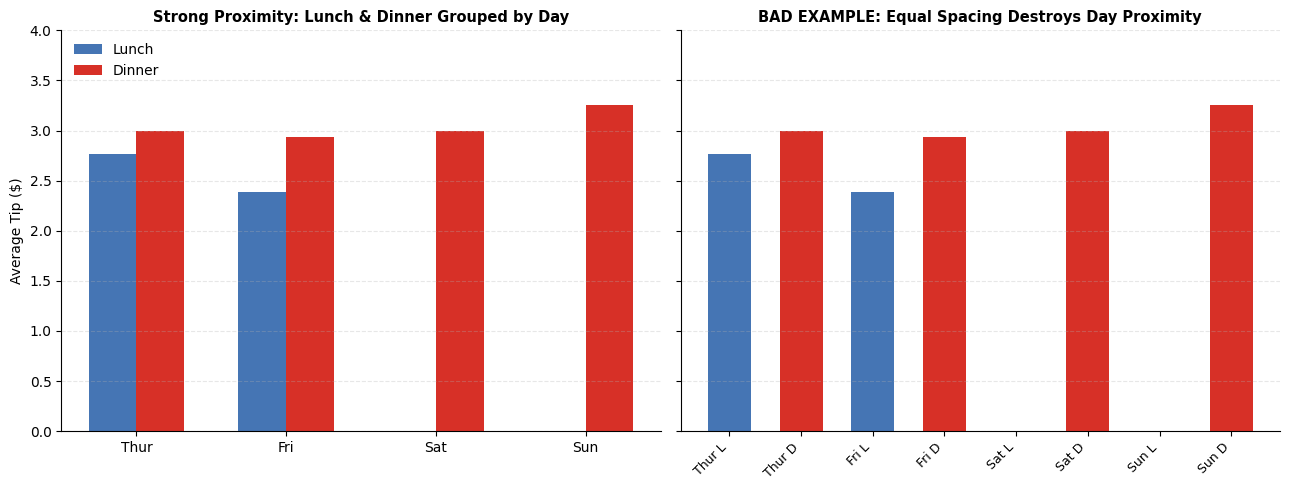

In [5]:
df_tips = pd.read_csv('data/tips.csv')

# Compute mean tip by day and time (Lunch vs Dinner)
grouped = df_tips.groupby(['day', 'time'])['tip'].mean().unstack().loc[['Thur', 'Fri', 'Sat', 'Sun']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# 1. Strong Proximity: tight gap within day, wide gap between days
x = np.arange(len(grouped))
w = 0.32
ax1.bar(x - w/2, grouped['Lunch'], width=w, label='Lunch', color='#4575b4')
ax1.bar(x + w/2, grouped['Dinner'], width=w, label='Dinner', color='#d73027')
ax1.set_xticks(x)
ax1.set_xticklabels(grouped.index)
ax1.set_title("Strong Proximity: Lunch & Dinner Grouped by Day", fontsize=10.5, fontweight='bold')
ax1.set_ylabel("Average Tip ($)")
ax1.set_ylim(bottom=0, top=4)
ax1.legend(frameon=False)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

# 2. Broken Proximity: equidistant bars across the entire axis
positions = [0, 0.9, 2.0, 2.9, 4.0, 4.9, 6.0, 6.9]
vals = [grouped.loc['Thur', 'Lunch'], grouped.loc['Thur', 'Dinner'],
        grouped.loc['Fri', 'Lunch'], grouped.loc['Fri', 'Dinner'],
        grouped.loc['Sat', 'Lunch'], grouped.loc['Sat', 'Dinner'],
        grouped.loc['Sun', 'Lunch'], grouped.loc['Sun', 'Dinner']]
labels = ['Thur L', 'Thur D', 'Fri L', 'Fri D', 'Sat L', 'Sat D', 'Sun L', 'Sun D']
cols = ['#4575b4', '#d73027'] * 4

# Uniformly spaced bars destroying day grouping
ax2.bar(range(8), vals, width=0.6, color=cols)
ax2.set_xticks(range(8))
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax2.set_title("BAD EXAMPLE: Equal Spacing Destroys Day Proximity", fontsize=10.5, fontweight='bold')
ax2.grid(True, axis='y', linestyle='--', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### Loss in Equal-Spacing Version
When spacing between within-day bars and between-day bars is made equal, the visual system no longer automatically groups Lunch and Dinner into single temporal units. The reader must mentally read and match tick labels, increasing extraneous cognitive load.

### Where Each Principle Lives in Real Charts
1. **Proximity:** Grouped bar charts use smaller spacing within categories than between categories.
2. **Similarity:** Categorical hue palettes give identical meaning to data points of the same series.
3. **Enclosure:** Shaded confidence bands or highlight boxes group relevant data intervals together.
4. **Closure:** Broken or dashed reference lines are perceived as continuous boundaries without cluttering background data.
5. **Continuity:** Line plots connect time-series points, guiding the eye along a smooth temporal trajectory.
6. **Connection:** Node-link graphs and network diagrams link entities directly with edges.

### Why Direct Labelling Beats Legends via Gestalt
A legend forces the brain to hold a color code in working memory, shift gaze across the canvas, and locate matching marks via similarity search. **Direct labelling relies on proximity** by placing text right beside the data point, eliminating eye transit and freeing working memory capacity.